In [ ]:
import torch

print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU ❌")

Torch version: 2.5.1+cu121
CUDA version: 12.1
CUDA available: True
GPU name: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
from abc import abstractmethod, ABCMeta
from collections import OrderedDict
from pathlib import Path
import torch.nn as nn
from torch.utils.data import Dataset
import datetime
import numpy as np
from torch.utils.data import DataLoader
import re
import matplotlib.pyplot as plt
from pyedflib import EdfReader
import pandas as pd

In [3]:
class ChbEdfFile(object):
    """
    Edf reader using pyedflib
    """
    def __init__(self, filename, patient_id=None):
        self._filename = filename
        self._patient_id = patient_id
        self._file = EdfReader(filename)

    def get_filename(self):
        return self._filename

    def get_n_channels(self):
        """
        Number of channels
        """
        return len(self._file.getSampleFrequencies())

    def get_n_data_points(self):
        """
        Number of data points
        """
        samples = self._file.getNSamples()

        if len(samples) < 1:
            raise ValueError("Number of channels is less than 1")

        return int(np.min(samples))
    def get_channel_names(self):
        """
        Names of channels
        """
        return self._file.getSignalLabels()

    def get_channel_scalings(self):
        """
        Channel scalings as an array
        :return:
        """
        out = np.zeros(self.get_n_channels())
        for i in range(self.get_n_channels()):
            out[i] = self._file.getPhysicalMaximum(i) - self._file.getPhysicalMinimum(i)
        return out

    def get_file_duration(self):
        """
        Returns the file duration in seconds
        """
        return self._file.getFileDuration()

    def get_sampling_rate(self):
        """
        Get the frequency
        """
        if len(self._file.getSampleFrequencies()) < 1:
            raise ValueError("Number of channels is less than 1")
        return self._file.getSampleFrequency(0)

    def get_channel_data(self, channel_id):
        """
        Get raw data for a single channel
        """
        if channel_id >= self.get_n_channels() or channel_id < 0:
            raise ValueError("Illegal channel id selected %d" % channel_id)
        return self._file.readSignal(channel_id)

    def get_data(self):
        
        n_channels = self.get_n_channels()
        n_samples_per_channel = self._file.getNSamples()

        min_samples = int(np.min(n_samples_per_channel))

        output_data = np.zeros((min_samples, n_channels), dtype=np.float32)

        for i in range(n_channels):
            sig = self._file.readSignal(i)

            if len(sig) < min_samples:
                raise ValueError(
                    f"Channel {i} has fewer samples than expected: {len(sig)} < {min_samples}"
                )

            output_data[:, i] = sig[:min_samples]

        return output_data

    def get_start_datetime(self):
        """
        Get the starting date and time
        """
        return self._file.getStartdatetime()

    def get_end_datetime(self):
        return self._file.getStartdatetime() + datetime.timedelta(seconds=self._file.getFileDuration())
    
    def close(self):
        self._file.close()

    def __del__(self):
        try:
            self._file.close()
        except:
            pass

In [4]:
edf = ChbEdfFile(r"D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mit-scalp-eeg-database-1.0.0\chb01\chb01_03.edf")

print("Channels:", edf.get_n_channels())
print("Sampling rate:", edf.get_sampling_rate())
print("Duration:", edf.get_file_duration())

data = edf.get_data()
print("Shape:", data.shape)

Channels: 23
Sampling rate: 256.0
Duration: 3600.0
Shape: (921600, 23)


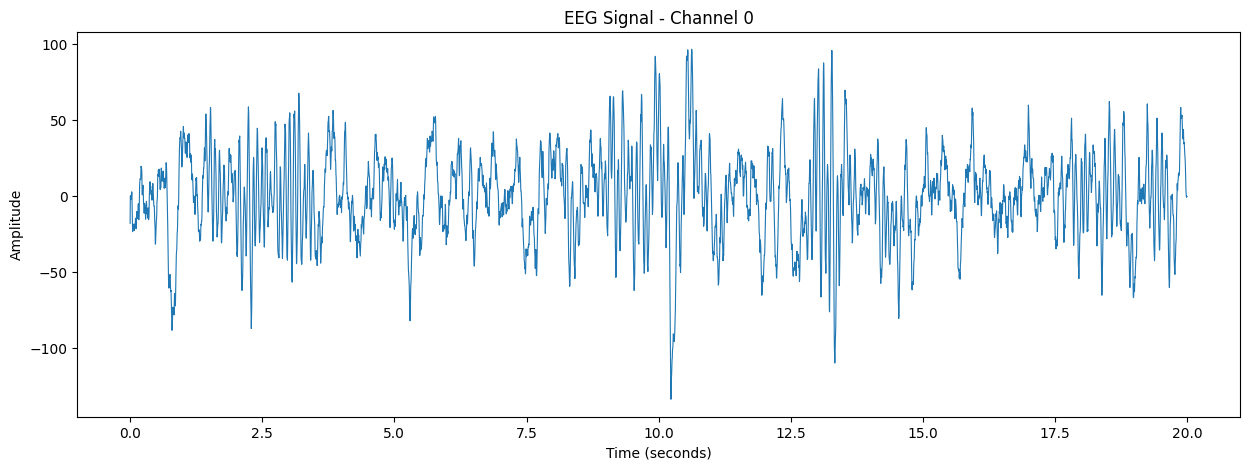

In [5]:
channel_id = 0

signal = edf.get_channel_data(channel_id)
fs = edf.get_sampling_rate()

seconds = 20
samples = int(seconds * fs)

time = np.arange(samples) / fs

plt.figure(figsize=(15,5))
plt.plot(time, signal[:samples], linewidth=0.8)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title(f"EEG Signal - Channel {channel_id}")
plt.show()

In [6]:
channel_names = edf.get_channel_names()

for i, name in enumerate(channel_names):
    print(i, "->", name)

0 -> FP1-F7
1 -> F7-T7
2 -> T7-P7
3 -> P7-O1
4 -> FP1-F3
5 -> F3-C3
6 -> C3-P3
7 -> P3-O1
8 -> FP2-F4
9 -> F4-C4
10 -> C4-P4
11 -> P4-O2
12 -> FP2-F8
13 -> F8-T8
14 -> T8-P8
15 -> P8-O2
16 -> FZ-CZ
17 -> CZ-PZ
18 -> P7-T7
19 -> T7-FT9
20 -> FT9-FT10
21 -> FT10-T8
22 -> T8-P8


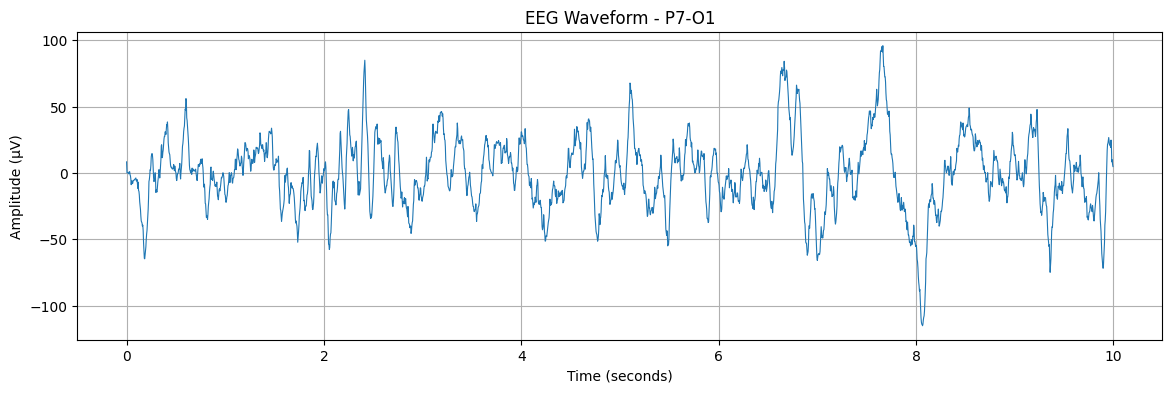

In [7]:
channel_name = channel_names[3]   
channel_id = channel_names.index(channel_name)

signal = edf.get_channel_data(channel_id)
fs = edf.get_sampling_rate()

seconds = 10
samples = int(seconds * fs)
time = np.arange(samples) / fs

plt.figure(figsize=(14, 4))
plt.plot(time, signal[:samples], linewidth=0.8)
plt.title(f"EEG Waveform - {channel_name}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.show()

In [8]:
class ChbLabelWrapper:
    def __init__(self, filename):
        self._filename = filename
        with open(filename, "r", encoding="utf-8", errors="ignore") as f:
            self._parse_file(f)

    def _parse_file(self, file_obj):
        text = file_obj.read()

        freq_match = re.search(r"Data Sampling Rate:\s*(\d+)\s*Hz", text)
        self._frequency = int(freq_match.group(1)) if freq_match else None

        self._channel_names = re.findall(r"Channel\s+\d+:\s*(.+)", text)

        self._metadata_store = OrderedDict()

        file_blocks = re.split(r"\n(?=File Name:)", text)

        for block in file_blocks:
            fname_match = re.search(r"File Name:\s*(.+)", block)
            if not fname_match:
                continue

            filename = fname_match.group(1).strip()

            start_match = re.search(r"File Start Time:\s*(.+)", block)
            end_match = re.search(r"File End Time:\s*(.+)", block)
            nsz_match = re.search(r"Number of Seizures in File:\s*(\d+)", block)

            n_seizures = int(nsz_match.group(1)) if nsz_match else 0

            starts = re.findall(r"Seizure\s*\d*\s*Start Time:\s*(\d+)\s*seconds", block)
            ends = re.findall(r"Seizure\s*\d*\s*End Time:\s*(\d+)\s*seconds", block)

            seizure_intervals = [(int(s), int(e)) for s, e in zip(starts, ends)]

            self._metadata_store[filename] = {
                "start_time": start_match.group(1).strip() if start_match else None,
                "end_time": end_match.group(1).strip() if end_match else None,
                "n_seizures": n_seizures,
                "seizure_intervals": seizure_intervals,
                "channel_names": self._channel_names,
                "sampling_rate": self._frequency,
            }

    def get_sampling_rate(self):
        return self._frequency

    def get_channel_names(self, filename=None):
        return self._channel_names

    def get_seizure_list(self):
        return [metadata["seizure_intervals"] for metadata in self._metadata_store.values()]

    def get_file_metadata(self):
        return self._metadata_store

In [9]:
summary_path = r"D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mit-scalp-eeg-database-1.0.0\chb01\chb01-summary.txt"

labels = ChbLabelWrapper(summary_path)

metadata = labels.get_file_metadata()

print("Sampling rate:", labels.get_sampling_rate())
print("Number of files:", len(metadata))

for filename, info in metadata.items():
    if info["n_seizures"] > 0:
        print(filename, "->", info["seizure_intervals"])

Sampling rate: 256
Number of files: 42
chb01_03.edf -> [(2996, 3036)]
chb01_04.edf -> [(1467, 1494)]
chb01_15.edf -> [(1732, 1772)]
chb01_16.edf -> [(1015, 1066)]
chb01_18.edf -> [(1720, 1810)]
chb01_21.edf -> [(327, 420)]
chb01_26.edf -> [(1862, 1963)]


In [10]:
patient_dir = Path(r"D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mit-scalp-eeg-database-1.0.0\chb01")
summary_path = patient_dir / "chb01-summary.txt"

labels = ChbLabelWrapper(str(summary_path))
metadata = labels.get_file_metadata()

edf_files = sorted(patient_dir.glob("*.edf"))

print("Patient folder:", patient_dir)
print("EDF files:", len(edf_files))
print("Files in summary:", len(metadata))

Patient folder: D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mit-scalp-eeg-database-1.0.0\chb01
EDF files: 42
Files in summary: 42


In [11]:
records = []

for edf_path in edf_files:
    filename = edf_path.name
    
    if filename in metadata:
        info = metadata[filename]
        records.append({
            "edf_path": edf_path,
            "filename": filename,
            "sampling_rate": info["sampling_rate"],
            "n_seizures": info["n_seizures"],
            "seizure_intervals": info["seizure_intervals"]
        })

print("Matched records:", len(records))

for r in records:
    if r["n_seizures"] > 0:
        print(r["filename"], r["seizure_intervals"])

Matched records: 42
chb01_03.edf [(2996, 3036)]
chb01_04.edf [(1467, 1494)]
chb01_15.edf [(1732, 1772)]
chb01_16.edf [(1015, 1066)]
chb01_18.edf [(1720, 1810)]
chb01_21.edf [(327, 420)]
chb01_26.edf [(1862, 1963)]


In [13]:
seizure_records = [r for r in records if r["n_seizures"] > 0]

record = seizure_records[0]

edf = ChbEdfFile(str(record["edf_path"]))

print("Selected file:", record["filename"])
print("Channels:", edf.get_n_channels())
print("Sampling rate:", edf.get_sampling_rate())
print("Duration:", edf.get_file_duration())
print("Seizures:", record["seizure_intervals"])

Selected file: chb01_03.edf
Channels: 23
Sampling rate: 256.0
Duration: 3600.0
Seizures: [(2996, 3036)]


In [14]:
ROOT = Path(r"D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mit-scalp-eeg-database-1.0.0")

patient_dirs = sorted([
    p for p in ROOT.iterdir()
    if p.is_dir() and re.match(r"^chb\d+$", p.name)
])

print("Patients found:", len(patient_dirs))
print([p.name for p in patient_dirs])

Patients found: 24
['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14', 'chb15', 'chb16', 'chb17', 'chb18', 'chb19', 'chb20', 'chb21', 'chb22', 'chb23', 'chb24']


In [15]:
dataset = {}

for patient_dir in patient_dirs:
    pid = patient_dir.name
    
    summary_candidates = [
        patient_dir / f"{pid}-summary.txt",
        patient_dir / f"{pid}_summary.txt",
        patient_dir / "summary.txt"
    ]
    
    summary_path = next((p for p in summary_candidates if p.exists()), None)
    edf_files = sorted(patient_dir.glob("*.edf"))
    
    dataset[pid] = {
        "dir": patient_dir,
        "summary": summary_path,
        "edf_files": edf_files
    }

for pid, info in dataset.items():
    print(pid, "| EDF:", len(info["edf_files"]), "| Summary:", info["summary"].name if info["summary"] else "Missing")

chb01 | EDF: 42 | Summary: chb01-summary.txt
chb02 | EDF: 36 | Summary: chb02-summary.txt
chb03 | EDF: 38 | Summary: chb03-summary.txt
chb04 | EDF: 42 | Summary: chb04-summary.txt
chb05 | EDF: 39 | Summary: chb05-summary.txt
chb06 | EDF: 18 | Summary: chb06-summary.txt
chb07 | EDF: 19 | Summary: chb07-summary.txt
chb08 | EDF: 20 | Summary: chb08-summary.txt
chb09 | EDF: 19 | Summary: chb09-summary.txt
chb10 | EDF: 25 | Summary: chb10-summary.txt
chb11 | EDF: 35 | Summary: chb11-summary.txt
chb12 | EDF: 24 | Summary: chb12-summary.txt
chb13 | EDF: 33 | Summary: chb13-summary.txt
chb14 | EDF: 26 | Summary: chb14-summary.txt
chb15 | EDF: 40 | Summary: chb15-summary.txt
chb16 | EDF: 19 | Summary: chb16-summary.txt
chb17 | EDF: 21 | Summary: chb17-summary.txt
chb18 | EDF: 36 | Summary: chb18-summary.txt
chb19 | EDF: 30 | Summary: chb19-summary.txt
chb20 | EDF: 29 | Summary: chb20-summary.txt
chb21 | EDF: 33 | Summary: chb21-summary.txt
chb22 | EDF: 31 | Summary: chb22-summary.txt
chb23 | ED

In [16]:
clean_dataset = {}

for pid, info in dataset.items():
    clean_edfs = [
        p for p in info["edf_files"]
        if "seizure" not in p.name.lower()
    ]
    
    clean_dataset[pid] = {
        **info,
        "edf_files": clean_edfs
    }

for pid, info in clean_dataset.items():
    print(pid, "| Clean EDF:", len(info["edf_files"]))

chb01 | Clean EDF: 42
chb02 | Clean EDF: 36
chb03 | Clean EDF: 38
chb04 | Clean EDF: 42
chb05 | Clean EDF: 39
chb06 | Clean EDF: 18
chb07 | Clean EDF: 19
chb08 | Clean EDF: 20
chb09 | Clean EDF: 19
chb10 | Clean EDF: 25
chb11 | Clean EDF: 35
chb12 | Clean EDF: 24
chb13 | Clean EDF: 33
chb14 | Clean EDF: 26
chb15 | Clean EDF: 40
chb16 | Clean EDF: 19
chb17 | Clean EDF: 21
chb18 | Clean EDF: 36
chb19 | Clean EDF: 30
chb20 | Clean EDF: 29
chb21 | Clean EDF: 33
chb22 | Clean EDF: 31
chb23 | Clean EDF: 9
chb24 | Clean EDF: 22


In [17]:
all_records = []

for pid, info in clean_dataset.items():
    if info["summary"] is None:
        continue
    
    labels = ChbLabelWrapper(str(info["summary"]))
    metadata = labels.get_file_metadata()
    
    for edf_path in info["edf_files"]:
        fname = edf_path.name
        
        if fname in metadata:
            meta = metadata[fname]
            
            all_records.append({
                "patient": pid,
                "path": edf_path,
                "sampling_rate": meta["sampling_rate"],
                "seizures": meta["seizure_intervals"],
                "n_seizures": meta["n_seizures"]
            })

print("Total records:", len(all_records))

Total records: 676


In [18]:
def label_windows_for_record(record, window_sec=5, overlap=0.5):
    fs = record["sampling_rate"]
    duration_sec = ChbEdfFile(str(record["path"])).get_file_duration()
    
    step_sec = window_sec * (1 - overlap)
    filename = record.get("filename", record["path"].name)
    
    windows = []
    start = 0.0
    
    while start + window_sec <= duration_sec:
        end = start + window_sec
        
        label = 0
        for sz_start, sz_end in record["seizures"]:
            if start < sz_end and end > sz_start:
                label = 1
                break
        
        windows.append({
            "patient": record["patient"],
            "filename": filename,
            "path": record["path"],
            "start_sec": start,
            "end_sec": end,
            "label": label
        })
        
        start += step_sec
    
    return windows

In [19]:
all_windows = []

for record in all_records:
    all_windows.extend(
        label_windows_for_record(record, window_sec=5, overlap=0.5)
    )

print("Total windows:", len(all_windows))
print("Seizure windows:", sum(w["label"] for w in all_windows))
print("Non-seizure windows:", len(all_windows) - sum(w["label"] for w in all_windows))

Total windows: 1401334
Seizure windows: 4999
Non-seizure windows: 1396335


In [20]:
windows_df = pd.DataFrame(all_windows)

windows_df.head()

,patient,filename,path,start_sec,end_sec,label
0,chb01,chb01_01.edf,D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mi...,0.0,5.0,0
1,chb01,chb01_01.edf,D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mi...,2.5,7.5,0
2,chb01,chb01_01.edf,D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mi...,5.0,10.0,0
3,chb01,chb01_01.edf,D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mi...,7.5,12.5,0
4,chb01,chb01_01.edf,D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mi...,10.0,15.0,0


In [21]:
print(windows_df.head())
print("\nClass balance:")
print(windows_df["label"].value_counts())

  patient      filename                                               path  \
0   chb01  chb01_01.edf  D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mi...   
1   chb01  chb01_01.edf  D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mi...   
2   chb01  chb01_01.edf  D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mi...   
3   chb01  chb01_01.edf  D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mi...   
4   chb01  chb01_01.edf  D:\chb-mit-scalp-eeg-database-1.0.0\EEG\chb-mi...   

   start_sec  end_sec  label  
0        0.0      5.0      0  
1        2.5      7.5      0  
2        5.0     10.0      0  
3        7.5     12.5      0  
4       10.0     15.0      0  

Class balance:
label
0    1396335
1       4999
Name: count, dtype: int64


In [22]:
class EEGDataset(Dataset):
    def __init__(self, df, n_channels=23):
        self.df = df.reset_index(drop=True)
        self.n_channels = n_channels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        edf = ChbEdfFile(str(row["path"]))

        try:
            fs = edf.get_sampling_rate()
            start = int(row["start_sec"] * fs)
            end = int(row["end_sec"] * fs)

            data = []

            for ch in range(min(self.n_channels, edf.get_n_channels())):
                sig = edf.get_channel_data(ch)
                data.append(sig[start:end])

            data = np.array(data, dtype=np.float32)

        finally:
            edf.close()

        mean = data.mean()
        std = data.std() + 1e-8
        data = (data - mean) / std

        x = torch.tensor(data, dtype=torch.float32)
        y = torch.tensor(row["label"], dtype=torch.float32)

        return x, y

In [23]:
dataset = EEGDataset(windows_df)

x, y = dataset[0]

print(x.shape)
print(y)

torch.Size([23, 1280])
tensor(0.)


In [24]:
print("Total windows in dataset:", len(dataset))
print("Windows dataframe shape:", windows_df.shape)

Total windows in dataset: 1401334
Windows dataframe shape: (1401334, 6)


In [25]:
print(windows_df["label"].value_counts())

label
0    1396335
1       4999
Name: count, dtype: int64


In [26]:
loader = DataLoader(dataset, batch_size=8, shuffle=True)

x_batch, y_batch = next(iter(loader))

print("Batch X shape:", x_batch.shape)
print("Batch y shape:", y_batch.shape)
print("Labels:", y_batch)

Batch X shape: torch.Size([8, 23, 1280])
Batch y shape: torch.Size([8])
Labels: tensor([0., 0., 0., 0., 0., 0., 0., 0.])


In [27]:
dataset = EEGDataset(windows_df)

In [28]:
print("Patients:", len(clean_dataset))
print(clean_dataset.keys())

Patients: 24
dict_keys(['chb01', 'chb02', 'chb03', 'chb04', 'chb05', 'chb06', 'chb07', 'chb08', 'chb09', 'chb10', 'chb11', 'chb12', 'chb13', 'chb14', 'chb15', 'chb16', 'chb17', 'chb18', 'chb19', 'chb20', 'chb21', 'chb22', 'chb23', 'chb24'])


In [29]:
print("Total records:", len(all_records))

Total records: 676


In [30]:
record_files = set(str(r["path"]) for r in all_records)

missing = []

for pid, info in clean_dataset.items():
    for edf_path in info["edf_files"]:
        if str(edf_path) not in record_files:
            missing.append(edf_path)

print("Missing EDF files:", len(missing))
missing[:20]

Missing EDF files: 10


[WindowsPath('D:/chb-mit-scalp-eeg-database-1.0.0/EEG/chb-mit-scalp-eeg-database-1.0.0/chb24/chb24_02.edf'),
 WindowsPath('D:/chb-mit-scalp-eeg-database-1.0.0/EEG/chb-mit-scalp-eeg-database-1.0.0/chb24/chb24_05.edf'),
 WindowsPath('D:/chb-mit-scalp-eeg-database-1.0.0/EEG/chb-mit-scalp-eeg-database-1.0.0/chb24/chb24_08.edf'),
 WindowsPath('D:/chb-mit-scalp-eeg-database-1.0.0/EEG/chb-mit-scalp-eeg-database-1.0.0/chb24/chb24_10.edf'),
 WindowsPath('D:/chb-mit-scalp-eeg-database-1.0.0/EEG/chb-mit-scalp-eeg-database-1.0.0/chb24/chb24_12.edf'),
 WindowsPath('D:/chb-mit-scalp-eeg-database-1.0.0/EEG/chb-mit-scalp-eeg-database-1.0.0/chb24/chb24_16.edf'),
 WindowsPath('D:/chb-mit-scalp-eeg-database-1.0.0/EEG/chb-mit-scalp-eeg-database-1.0.0/chb24/chb24_18.edf'),
 WindowsPath('D:/chb-mit-scalp-eeg-database-1.0.0/EEG/chb-mit-scalp-eeg-database-1.0.0/chb24/chb24_19.edf'),
 WindowsPath('D:/chb-mit-scalp-eeg-database-1.0.0/EEG/chb-mit-scalp-eeg-database-1.0.0/chb24/chb24_20.edf'),
 WindowsPath('D:/ch

In [31]:
print("Total windows:", len(windows_df))
print(windows_df["patient"].value_counts().sort_index())

Total windows: 1401334
patient
chb01     58353
chb02     50747
chb03     54684
chb04    224686
chb05     56125
chb06     96079
chb07     96535
chb08     28789
chb09     97713
chb10     72007
chb11     50067
chb12     34093
chb13     47487
chb14     37414
chb15     57573
chb16     27341
chb17     30228
chb18     51277
chb19     43067
chb20     39714
chb21     47242
chb22     44613
chb23     38232
chb24     17268
Name: count, dtype: int64


In [32]:
print(windows_df["label"].value_counts())

label
0    1396335
1       4999
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    windows_df,
    test_size=0.2,
    stratify=windows_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)

print("Train labels:")
print(train_df["label"].value_counts())

print("Val labels:")
print(val_df["label"].value_counts())

Train: (1121067, 7)
Val: (280267, 7)
Train labels:
label
0    1117068
1       3999
Name: count, dtype: int64
Val labels:
label
0    279267
1      1000
Name: count, dtype: int64


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EEGNet(nn.Module):
    def __init__(self, n_channels=23):
        super().__init__()

        self.conv1 = nn.Conv1d(n_channels, 32, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)

        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(128 * 160, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 1280 -> 640
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 640 -> 320
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 320 -> 160

        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = EEGNet(n_channels=23).to(device)

neg = (train_df["label"] == 0).sum()
pos = (train_df["label"] == 1).sum()

pos_weight = torch.tensor([neg / pos], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print("pos_weight:", pos_weight.item())
print(model)

Device: cuda
pos_weight: 279.3368225097656
EEGNet(
  (conv1): Conv1d(23, 32, kernel_size=(7,), stride=(1,), padding=(3,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=20480, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


In [ ]:
import time
from tqdm import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    start_time = time.time()

    progress = tqdm(loader, desc="Training", leave=True)

    for batch_idx, (x, y) in enumerate(progress):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        elapsed = time.time() - start_time
        batches_done = batch_idx + 1
        batches_total = len(loader)
        avg_time = elapsed / batches_done
        eta = avg_time * (batches_total - batches_done)

        progress.set_postfix({
            "loss": f"{loss.item():.4f}",
            "avg_loss": f"{total_loss / batches_done:.4f}",
            "ETA_min": f"{eta / 60:.1f}"
        })

    return total_loss / len(loader)

In [ ]:
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in tqdm(loader, desc="Validation", leave=True):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True).unsqueeze(1)

            logits = model(x)
            loss = criterion(logits, y)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            total_loss += loss.item()
            correct += (preds == y).sum().item()
            total += y.numel()

    return total_loss / len(loader), correct / total

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader, Sampler
import numpy as np
import random
from collections import defaultdict

class WindowMetaDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "cache_path": row["cache_path"],
            "start_sec": row["start_sec"],
            "label": row["label"]
        }

In [ ]:
class SameFileBatchSampler(Sampler):
    def __init__(self, df, batch_size=128, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.groups = defaultdict(list)
        for idx, path in enumerate(self.df["cache_path"]):
            self.groups[path].append(idx)

    def __iter__(self):
        paths = list(self.groups.keys())

        if self.shuffle:
            random.shuffle(paths)

        for path in paths:
            indices = self.groups[path].copy()

            if self.shuffle:
                random.shuffle(indices)

            for i in range(0, len(indices), self.batch_size):
                yield indices[i:i+self.batch_size]

    def __len__(self):
        total = 0
        for indices in self.groups.values():
            total += (len(indices) + self.batch_size - 1) // self.batch_size
        return total

In [ ]:
def smart_collate(batch, target_channels=23, target_samples=1280, fs=256):
    cache_path = batch[0]["cache_path"]

    data = np.load(cache_path)

    xs = []
    ys = []

    for item in batch:
        start = int(item["start_sec"] * fs)
        end = start + target_samples

        x = data[:, start:end]

        if x.shape[1] < target_samples:
            x = np.pad(x, ((0, 0), (0, target_samples - x.shape[1])), mode="constant")

        if x.shape[0] < target_channels:
            x = np.pad(x, ((0, target_channels - x.shape[0]), (0, 0)), mode="constant")

        if x.shape[0] > target_channels:
            x = x[:target_channels, :]

        xs.append(x)
        ys.append(item["label"])

    xs = torch.tensor(np.stack(xs), dtype=torch.float32)
    ys = torch.tensor(ys, dtype=torch.float32)

    return xs, ys

In [ ]:
train_dataset = WindowMetaDataset(train_df)
val_dataset = WindowMetaDataset(val_df)

train_sampler = SameFileBatchSampler(train_df, batch_size=128, shuffle=True)
val_sampler = SameFileBatchSampler(val_df, batch_size=128, shuffle=False)

train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_sampler,
    collate_fn=smart_collate,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_sampler=val_sampler,
    collate_fn=smart_collate,
    num_workers=0,
    pin_memory=True
)

In [ ]:
from pathlib import Path
import numpy as np

RAW_CACHE_DIR = Path("raw_edf_cache")

bad_cache_files = []

for p in RAW_CACHE_DIR.glob("*.npy"):
    try:
        _ = np.load(p)
    except Exception as e:
        bad_cache_files.append(p)

print("Bad cache files:", len(bad_cache_files))

for p in bad_cache_files:
    print("Deleting:", p)
    p.unlink()

Bad cache files: 1
Deleting: raw_edf_cache\chb19_24.npy


In [ ]:
record_cache = {}

for record in all_records:
    edf_path = Path(record["path"])
    cache_path = RAW_CACHE_DIR / f"{edf_path.stem}.npy"
    
    if cache_path.exists() and cache_path.stat().st_size > 0:
        record_cache[str(edf_path)] = str(cache_path)
        continue
    
    edf = ChbEdfFile(str(edf_path))
    
    try:
        n_ch = min(23, edf.get_n_channels())
        
        data = np.array([
            edf.get_channel_data(ch)
            for ch in range(n_ch)
        ], dtype=np.float32)
        
        data = (data - data.mean()) / (data.std() + 1e-8)
        
        np.save(cache_path, data)
        record_cache[str(edf_path)] = str(cache_path)
        
    finally:
        edf.close()

print("Cached:", len(record_cache))

Cached: 676


In [ ]:
windows_df["cache_path"] = windows_df["path"].astype(str).map(record_cache)

print("Missing cache:", windows_df["cache_path"].isna().sum())

Missing cache: 0


In [ ]:
import torch
import time

EPOCHS = 15
best_val_loss = float("inf")
patience = 5
patience_counter = 0

start_training_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    epoch_start = time.time()

    # ---- Training ----
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # ---- Validation ----
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    epoch_time = (time.time() - epoch_start) / 60  # minutes
    total_time = (time.time() - start_training_time) / 60

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Epoch time: {epoch_time:.1f} min | Total time: {total_time:.1f} min")

    # ---- Save best model ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch + 1,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }, "best_eeg_model.pth")

        print("✅ Best model saved")

    else:
        patience_counter += 1
        print(f"No improvement: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("🛑 Early stopping triggered")
            break

print("\n🎯 Training finished")
print(f"Best Val Loss: {best_val_loss:.4f}")


Epoch 1/15


Training:   0%|          | 0/9086 [00:00<?, ?it/s]

Validation: 100%|██████████| 2648/2648 [08:55<00:00,  4.95it/s]


Train Loss: 0.4252
Val Loss: 1.5298
Val Accuracy: 0.8643
Epoch time: 40.9 min | Total time: 40.9 min
✅ Best model saved

Epoch 2/15


Validation: 100%|██████████| 2648/2648 [08:51<00:00,  4.99it/s]


...

Train Loss: 0.3239
Val Loss: 1.4858
Val Accuracy: 0.8773
Epoch time: 40.3 min | Total time: 202.5 min
No improvement: 3/5

Epoch 6/15


Validation: 100%|██████████| 2648/2648 [09:04<00:00,  4.87it/s]


Train Loss: 0.3629
Val Loss: 1.9468
Val Accuracy: 0.3296
Epoch time: 39.8 min | Total time: 242.3 min
No improvement: 4/5

Epoch 7/15


Validation: 100%|██████████| 2648/2648 [08:44<00:00,  5.05it/s]

Train Loss: 0.2827
Val Loss: 1.7487
Val Accuracy: 0.8914
Epoch time: 39.6 min | Total time: 281.9 min
No improvement: 5/5
🛑 Early stopping triggered

🎯 Training finished
Best Val Loss: 1.2541


In [ ]:
checkpoint = torch.load("best_eeg_model.pth", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(val_loader, desc="Final Evaluation"):
        x = x.to(device, non_blocking=True)
        
        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        preds = (probs > 0.5).astype(int)
        
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y.numpy().astype(int))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Non-seizure", "Seizure"],
    digits=4
))

C:\Users\Mohamed Ayman\AppData\Local\Temp\ipykernel_18152\4161490934.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_eeg_model.pth", map_lo

Confusion Matrix:
[[254268  24999]
 [   290    710]]

Classification Report:
              precision    recall  f1-score   support

 Non-seizure     0.9989    0.9105    0.9526    279267
     Seizure     0.0276    0.7100    0.0532      1000

    accuracy                         0.9098    280267
   macro avg     0.5132    0.8102    0.5029    280267
weighted avg     0.9954    0.9098    0.9494    280267



In [ ]:
thresholds = [0.5, 0.7, 0.8, 0.9, 0.95]

for t in thresholds:
    preds = (np.array(all_probs) > t).astype(int)
    
    from sklearn.metrics import precision_score, recall_score, f1_score
    
    p = precision_score(all_labels, preds)
    r = recall_score(all_labels, preds)
    f1 = f1_score(all_labels, preds)
    
    print(f"Threshold {t}: Precision={p:.4f} Recall={r:.4f} F1={f1:.4f}")

Threshold 0.5: Precision=0.0276 Recall=0.7100 F1=0.0532
Threshold 0.7: Precision=0.0390 Recall=0.6560 F1=0.0737
Threshold 0.8: Precision=0.0475 Recall=0.6150 F1=0.0883
Threshold 0.9: Precision=0.0661 Recall=0.5690 F1=0.1184
Threshold 0.95: Precision=0.0900 Recall=0.5060 F1=0.1528


In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.view(-1, 1).float()

        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)

        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(
            targets == 1,
            torch.tensor(self.alpha, device=logits.device),
            torch.tensor(1 - self.alpha, device=logits.device)
        )

        loss = alpha_t * (1 - pt) ** self.gamma * bce
        return loss.mean()


# Use Focal Loss instead of BCEWithLogitsLoss(pos_weight=...)
criterion = FocalLoss(alpha=0.75, gamma=2.0)

# Fresh optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 5
best_val_loss = float("inf")
patience = 2
patience_counter = 0

start_training_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS} — Focal Loss")
    epoch_start = time.time()

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    epoch_time = (time.time() - epoch_start) / 60
    total_time = (time.time() - start_training_time) / 60

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Epoch time: {epoch_time:.1f} min | Total time: {total_time:.1f} min")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch + 1,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }, "best_eeg_model_focal.pth")

        print("✅ Best focal model saved")
    else:
        patience_counter += 1
        print(f"No improvement: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("🛑 Early stopping triggered")
            break

print("\n🎯 Focal Loss training finished")
print(f"Best Val Loss: {best_val_loss:.4f}")


Epoch 1/5 — Focal Loss


Validation: 100%|██████████| 2648/2648 [09:02<00:00,  4.88it/s]


Train Loss: 0.0020
Val Loss: 0.0058
Val Accuracy: 0.9968
Epoch time: 40.4 min | Total time: 40.4 min
✅ Best focal model saved

Epoch 2/5 — Focal Loss


Validation: 100%|██████████| 2648/2648 [08:58<00:00,  4.92it/s]


Train Loss: 0.0016
Val Loss: 0.0098
Val Accuracy: 0.9912
Epoch time: 40.7 min | Total time: 81.1 min
No improvement: 1/2

Epoch 3/5 — Focal Loss


...

Train Loss: 0.0016
Val Loss: 0.0048
Val Accuracy: 0.9933
Epoch time: 40.5 min | Total time: 121.6 min
✅ Best focal model saved

Epoch 4/5 — Focal Loss


Validation: 100%|██████████| 2648/2648 [08:54<00:00,  4.95it/s]


Train Loss: 0.0019
Val Loss: 0.0215
Val Accuracy: 0.8753
Epoch time: 40.5 min | Total time: 162.1 min
No improvement: 1/2

Epoch 5/5 — Focal Loss


Validation: 100%|██████████| 2648/2648 [09:04<00:00,  4.86it/s]

Train Loss: 0.0012
Val Loss: 0.0073
Val Accuracy: 0.9965
Epoch time: 40.6 min | Total time: 202.7 min
No improvement: 2/2
🛑 Early stopping triggered

🎯 Focal Loss training finished
Best Val Loss: 0.0048


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import torch
from tqdm import tqdm

checkpoint = torch.load("best_eeg_model_focal.pth", map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(val_loader, desc="Final Focal Evaluation"):
        x = x.to(device, non_blocking=True)

        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy().ravel()
        preds = (probs > 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y.numpy().astype(int))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_preds,
    target_names=["Non-seizure", "Seizure"],
    digits=4
))

C:\Users\Mohamed Ayman\AppData\Local\Temp\ipykernel_18152\3177337858.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_eeg_model_focal.pth", 

Confusion Matrix:
[[278026   1241]
 [   627    373]]

Classification Report:
              precision    recall  f1-score   support

 Non-seizure     0.9977    0.9956    0.9967    279267
     Seizure     0.2311    0.3730    0.2854      1000

    accuracy                         0.9933    280267
   macro avg     0.6144    0.6843    0.6410    280267
weighted avg     0.9950    0.9933    0.9941    280267



In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import pandas as pd

thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for t in thresholds:
    preds = (np.array(all_probs) > t).astype(int)
    
    precision = precision_score(all_labels, preds, zero_division=0)
    recall = recall_score(all_labels, preds, zero_division=0)
    f1 = f1_score(all_labels, preds, zero_division=0)
    
    tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()
    
    results.append({
        "threshold": round(t, 2),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

threshold_df = pd.DataFrame(results)

threshold_df.sort_values("f1", ascending=False).head(10)

,threshold,precision,recall,f1,TP,FP,FN,TN
12,0.65,0.375489,0.288,0.325976,288,479,712,278788
11,0.60,0.326284,0.324,0.325138,324,669,676,278598
13,0.70,0.432937,0.255,0.320957,255,334,745,278933
10,0.55,0.277165,0.352,0.310132,352,918,648,278349
14,0.75,0.514151,0.218,0.306180,218,206,782,279061
9,0.50,0.231103,0.373,0.285386,373,1241,627,278026
15,0.80,0.609428,0.181,0.279106,181,116,819,279151
8,0.45,0.193343,0.395,0.259612,395,1648,605,277619
16,0.85,0.728155,0.150,0.248756,150,56,850,279211
7,0.40,0.161980,0.432,0.235615,432,2235,568,277032


In [ ]:
best_row = threshold_df.sort_values("f1", ascending=False).iloc[0]

best_threshold = best_row["threshold"]

print("Best threshold:", best_threshold)
print(best_row)

Best threshold: 0.65
threshold         0.650000
precision         0.375489
recall            0.288000
f1                0.325976
TP              288.000000
FP              479.000000
FN              712.000000
TN           278788.000000
Name: 12, dtype: float64


In [ ]:
from sklearn.metrics import classification_report

best_preds = (np.array(all_probs) > best_threshold).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(all_labels, best_preds))

print("\nClassification Report:")
print(classification_report(
    all_labels,
    best_preds,
    target_names=["Non-seizure", "Seizure"],
    digits=4
))

Confusion Matrix:
[[278788    479]
 [   712    288]]

Classification Report:
              precision    recall  f1-score   support

 Non-seizure     0.9975    0.9983    0.9979    279267
     Seizure     0.3755    0.2880    0.3260      1000

    accuracy                         0.9958    280267
   macro avg     0.6865    0.6431    0.6619    280267
weighted avg     0.9952    0.9958    0.9955    280267

